In [ ]:
import gc
import os
import sys
import psutil
import pyarrow as pa
from pathlib import Path
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from tqdm import tqdm
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
sys.path.insert(0, "../support/")
from paths import resolve

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
_NCPU = os.cpu_count() - 1 or 1
_TOTAL_MEMORY = psutil.virtual_memory().total
_AVAILABLE_MEMORY = psutil.virtual_memory().available
_MEMORY_PER_WORKER = max(100 * 1024**2, _AVAILABLE_MEMORY // (_NCPU + 1))
pa.set_cpu_count(_NCPU)
pa.set_io_thread_count(_NCPU)
os.environ["NUMEXPR_MAX_THREADS"] = str(_NCPU)
os.environ["NUMEXPR_NUM_THREADS"] = str(_NCPU)
os.environ.setdefault("OMP_NUM_THREADS", str(_NCPU))
os.environ.setdefault("OPENBLAS_NUM_THREADS", str(_NCPU))
os.environ.setdefault("MKL_NUM_THREADS", str(_NCPU))
print(f"Running with {_NCPU} CPU cores | {_TOTAL_MEMORY / 1024**3:.1f}GB total RAM ({_AVAILABLE_MEMORY / 1024**3:.1f}GB available) | pyarrow {pa.__version__}", flush=True)


Running with 47 CPU cores | 92.3GB total RAM (88.0GB available) | pyarrow 24.0.0


Variables

In [2]:
%run ../0_Config/0_variables.ipynb

Remove duplicate features (post-ranking)

In [3]:
import time as _time

_stem = Path(os.environ['FEATURE_DATASET']).stem
_fd_path = resolve(f"3_Features_select/Selected_features/{os.environ['TARGET']}_feature_data_{_stem}.parquet")
print(f"Loading feature_data parquet: {_fd_path}", flush=True)
_t = _time.perf_counter()
feature_data = pd.read_parquet(_fd_path)
print(f"  loaded feature_data: shape={feature_data.shape} in {_time.perf_counter() - _t:.1f}s", flush=True)

print(f"Loading features parquet: {os.environ['FEATURES_PATH']}", flush=True)
_t = _time.perf_counter()
features = pd.read_parquet(os.environ["FEATURES_PATH"], filters=[
    ('SETTLEMENTDATE', '>=', pd.Timestamp(os.environ["FEATURE_DATASET_START"])),
    ('SETTLEMENTDATE', '<=', pd.Timestamp(os.environ["FEATIRE_DATASET_END"])),
])
features = features.drop(columns=[c for c in features.columns if c in set(os.environ["TARGET_COLS"].split(","))])
features = features.loc[:pd.Timestamp(os.environ["FEATIRE_DATASET_END"])]
print(f"  loaded features: shape={features.shape} in {_time.perf_counter() - _t:.1f}s", flush=True)

def remove_duplicate_features(feature_data, features_full):
    LINEAR_CORR_THRESHOLD = 0.95     # |Pearson| above this → linear duplicate
    NONLINEAR_CORR_THRESHOLD = 0.95  # |Spearman| above this → monotonic non-linear duplicate

    ranked_features = feature_data["feature"].tolist()  # already sorted best → worst by mean_mi

    cols_present = [f for f in ranked_features if f in features_full.columns]
    features_full = features_full[cols_present]

    n_rows_total = len(features_full)
    n_rows = min(int(os.environ["DEDUP_SUBSAMPLE_AMOUNT"]), n_rows_total)
    if n_rows < n_rows_total:
        rng = np.random.default_rng(42)
        subsample_idx = np.sort(rng.choice(n_rows_total, size=n_rows, replace=False))
        features_full = features_full.iloc[subsample_idx]

    n_rows, n_features = features_full.shape
    print(
        f"Standardising {n_rows:,} rows × {n_features} features "
        f"(subsample of {n_rows_total:,} total rows)...",
        flush=True,
    )

    # Materialise as a single contiguous float32 ndarray once — downstream stats use BLAS / vectorised ops.
    # to_numpy(copy=False) skips an unnecessary cast when the underlying block is already float32.
    _t = _time.perf_counter()
    X_full = features_full.to_numpy(dtype=np.float32, copy=False)
    if not X_full.flags["C_CONTIGUOUS"]:
        X_full = np.ascontiguousarray(X_full)
    print(f"  feature ndarray ready in {_time.perf_counter() - _t:.1f}s ({X_full.nbytes / 1024**2:.0f}MB | contiguous={X_full.flags['C_CONTIGUOUS']})", flush=True)

    # Standardise columns → Pearson corr = (Z.T @ Z) / n_rows per column pair.
    # Vectorised numpy mean/std over axis=0 is multi-threaded via the BLAS reduction kernels.
    _t = _time.perf_counter()
    col_means = X_full.mean(axis=0)
    col_stds = X_full.std(axis=0)
    col_stds = np.where(col_stds == 0, np.float32(1.0), col_stds).astype(np.float32)
    Z_pearson = ((X_full - col_means) / col_stds).astype(np.float32, copy=False)
    print(f"  Pearson Z built in {_time.perf_counter() - _t:.1f}s ({Z_pearson.nbytes / 1024**2:.0f}MB)", flush=True)

    # Rank then standardise → Spearman via same dot product trick.
    # Pandas .rank() is single-threaded across columns; parallelise with joblib threading +
    # scipy.stats.rankdata (releases the GIL inside the C kernel). One task per column chunk
    # so total tasks = max(_NCPU * 4, ...) → all cores stay saturated.
    from scipy.stats import rankdata as _rankdata
    print(f"  ranking {n_features} columns for Spearman in parallel across {_NCPU} threads", flush=True)
    _t = _time.perf_counter()
    _target_tasks = max(_NCPU * 4, 16)
    _n_chunks = max(1, min(n_features, _target_tasks))
    _chunk_size = max(1, (n_features + _n_chunks - 1) // _n_chunks)
    _chunks = [(s, min(s + _chunk_size, n_features)) for s in range(0, n_features, _chunk_size)]

    def _rank_chunk(cs, ce):
        out = np.empty((n_rows, ce - cs), dtype=np.float32)
        for j, c in enumerate(range(cs, ce)):
            out[:, j] = _rankdata(X_full[:, c], method="average").astype(np.float32, copy=False)
        return cs, ce, out

    ranks_arr = np.empty_like(X_full)
    _gen = Parallel(n_jobs=_NCPU, backend="threading", batch_size=1, return_as="generator_unordered")(
        delayed(_rank_chunk)(cs, ce) for (cs, ce) in _chunks
    )
    for cs, ce, chunk in tqdm(_gen, total=len(_chunks), desc="rank columns", leave=False):
        ranks_arr[:, cs:ce] = chunk
    rank_means = ranks_arr.mean(axis=0)
    rank_stds = ranks_arr.std(axis=0)
    rank_stds = np.where(rank_stds == 0, np.float32(1.0), rank_stds).astype(np.float32)
    Z_spearman = ((ranks_arr - rank_means) / rank_stds).astype(np.float32, copy=False)
    del ranks_arr
    del X_full, col_means, col_stds, rank_means, rank_stds
    gc.collect()
    print(f"  Spearman Z built in {_time.perf_counter() - _t:.1f}s ({Z_spearman.nbytes / 1024**2:.0f}MB)", flush=True)

    col_index = {col: i for i, col in enumerate(cols_present)}

    kept_indices = []  # column positions of kept features in Z_pearson / Z_spearman
    duplicate_flags = {}

    print(f"  scanning {len(ranked_features)} features for duplicates (greedy MI-rank order)", flush=True)
    _t = _time.perf_counter()
    for feature in tqdm(ranked_features, desc="Deduplicating features", leave=True):
        if feature not in col_index:
            # feature absent from the loaded parquet — keep unconditionally
            duplicate_flags[feature] = False
            continue
        fi = col_index[feature]
        if not kept_indices:
            duplicate_flags[feature] = False
            kept_indices.append(fi)
            continue

        kept_arr = np.array(kept_indices)
        # Dot candidate column against each kept column → correlation vector; O(n_kept × n_rows)
        pearson_vals = np.abs(Z_pearson[:, fi] @ Z_pearson[:, kept_arr]) / n_rows
        spearman_vals = np.abs(Z_spearman[:, fi] @ Z_spearman[:, kept_arr]) / n_rows
        is_dup = bool(pearson_vals.max() > LINEAR_CORR_THRESHOLD or spearman_vals.max() > NONLINEAR_CORR_THRESHOLD)
        duplicate_flags[feature] = is_dup
        if not is_dup:
            kept_indices.append(fi)
    print(f"  dedup scan complete in {_time.perf_counter() - _t:.1f}s", flush=True)

    feature_data_flagged = feature_data.copy()
    feature_data_flagged["is_duplicate"] = feature_data_flagged["feature"].map(duplicate_flags)

    n_kept = feature_data_flagged["is_duplicate"].eq(False).sum()
    n_removed = feature_data_flagged["is_duplicate"].eq(True).sum()
    print(
        f"Kept {n_kept} unique features, flagged {n_removed} duplicates "
        f"(Pearson threshold={LINEAR_CORR_THRESHOLD}, Spearman threshold={NONLINEAR_CORR_THRESHOLD})",
        flush=True,
    )

    feature_data_unique = feature_data_flagged[feature_data_flagged["is_duplicate"] == False].reset_index(drop=True)

    display(feature_data_unique[:3])

    return feature_data_unique, feature_data_flagged, features_full


feature_data_unique, feature_data_flagged, features_subsampled = remove_duplicate_features(feature_data, features)
del features, feature_data
gc.collect()

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
print(f"Writing dedup outputs (flagged, unique, features_subsampled)", flush=True)
_t = _time.perf_counter()
feature_data_flagged.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)
feature_data_unique.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_unique_{_stem}.parquet")
)
features_subsampled.to_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_features_subsampled_{_stem}.parquet")
)
print(f"  writes done in {_time.perf_counter() - _t:.1f}s", flush=True)


Loading feature_data parquet: /home/ec2-user/Forecasting/3_Features_select/../3_Features_select/Selected_features/NSW_feature_data_1_dispatch_price.parquet
  loaded feature_data: shape=(634, 101) in 0.0s
Loading features parquet: /home/ec2-user/Forecasting/3_Features_select/../2_Features_build/Feature_data/1_dispatch_price.parquet
  loaded features: shape=(736417, 634) in 1.4s
Standardising 200,000 rows × 634 features (subsample of 736,417 total rows)...
  feature ndarray ready in 0.4s (484MB | contiguous=True)
  Pearson Z built in 0.7s (484MB)
  ranking 634 columns for Spearman in parallel across 47 threads


  Spearman Z built in 2.3s (484MB)
  scanning 634 features for duplicates (greedy MI-rank order)


Deduplicating features: 100%|██████████| 634/634 [04:13<00:00,  2.50it/s]

  dedup scan complete in 253.9s
Kept 440 unique features, flagged 194 duplicates (Pearson threshold=0.95, Spearman threshold=0.95)


,feature,rank,mean_mi,target,feature_dataset,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,h25,h26,h27,h28,h29,h30,h31,h32,h33,h34,h35,h36,h37,h38,h39,h40,h41,h42,h43,h44,h45,h46,h47,h48,h49,h50,h51,h52,h53,h54,h55,h56,h57,h58,h59,h60,h61,h62,h63,h64,h65,h66,h67,h68,h69,h70,h71,h72,h73,h74,h75,h76,h77,h78,h79,h80,h81,h82,h83,h84,h85,h86,h87,h88,h89,h90,h91,h92,h93,h94,h95,h96,is_duplicate
0,nsw_price_q90_336,1,0.837878,NSW,1_dispatch_price,0.950705,0.926782,0.912109,0.895848,0.883318,0.874949,0.861987,0.860274,0.851661,0.845989,0.839568,0.838834,0.838926,0.840020,0.847188,0.851285,0.850297,0.853766,0.848481,0.845089,0.846129,0.847760,0.839731,0.851217,0.845775,0.842526,0.846055,0.845617,0.835627,0.833919,0.834475,0.834990,0.833212,0.834770,0.837920,0.841120,0.854848,0.857009,0.859746,0.866942,0.868670,0.879866,0.890947,0.889223,0.895265,0.898173,0.884260,0.875929,0.863112,0.853694,0.839088,0.838118,0.823311,0.815871,0.808456,0.810787,0.801101,0.797696,0.794344,0.793258,0.799978,0.793709,0.803005,0.805723,0.805581,0.808263,0.806967,0.810570,0.801654,0.806925,0.808775,0.811499,0.802642,0.804334,0.800346,0.804587,0.801661,0.794225,0.798425,0.796425,0.797189,0.797124,0.794834,0.802387,0.806417,0.810305,0.822896,0.822621,0.830961,0.836018,0.847147,0.854348,0.861311,0.863496,0.851025,0.845321,False
1,qld_price_q90_336,2,0.820431,NSW,1_dispatch_price,0.901699,0.884745,0.875009,0.857989,0.851772,0.845726,0.839024,0.832097,0.827308,0.821402,0.810707,0.816850,0.813884,0.822161,0.826763,0.826343,0.826868,0.829329,0.826015,0.824453,0.825155,0.831233,0.827192,0.833182,0.828110,0.831360,0.832512,0.832551,0.828823,0.822935,0.820638,0.821115,0.819743,0.821382,0.819371,0.821434,0.827416,0.832785,0.840072,0.843878,0.844776,0.859293,0.869472,0.873901,0.879550,0.877780,0.865643,0.858122,0.844157,0.837032,0.822227,0.816472,0.805683,0.795935,0.793103,0.790933,0.785380,0.784102,0.777009,0.777828,0.784508,0.786506,0.789425,0.789775,0.788051,0.787632,0.787941,0.791300,0.787573,0.791019,0.791947,0.793861,0.793090,0.800278,0.791584,0.799503,0.797811,0.792300,0.789579,0.786681,0.787711,0.789172,0.791260,0.791146,0.793849,0.800746,0.804438,0.815400,0.820346,0.825107,0.837420,0.841363,0.850579,0.847373,0.836903,0.828730,False
2,nsw_price_q10_336,3,0.802289,NSW,1_dispatch_price,0.918259,0.897682,0.885073,0.866261,0.857136,0.848548,0.847000,0.840725,0.838757,0.836334,0.822819,0.828960,0.820621,0.817962,0.806804,0.808986,0.803749,0.805756,0.795695,0.791901,0.792996,0.792847,0.786388,0.790973,0.789123,0.793778,0.798192,0.799823,0.793022,0.796399,0.799612,0.798895,0.798213,0.798059,0.802693,0.810554,0.814483,0.816369,0.820091,0.828386,0.832283,0.834218,0.841146,0.838008,0.840661,0.838733,0.832593,0.824404,0.821145,0.816867,0.804505,0.800587,0.793280,0.792408,0.797394,0.795037,0.795488,0.791653,0.786046,0.784550,0.785650,0.778047,0.780461,0.780048,0.769239,0.765825,0.764848,0.764213,0.756509,0.760835,0.760359,0.757578,0.759399,0.763964,0.764718,0.770970,0.773568,0.767007,0.769258,0.769427,0.770256,0.769264,0.770898,0.771646,0.777948,0.778397,0.779903,0.788851,0.791366,0.794429,0.805208,0.807102,0.814386,0.808204,0.807012,0.801975,False


Writing dedup outputs (flagged, unique, features_subsampled)
  writes done in 8.2s


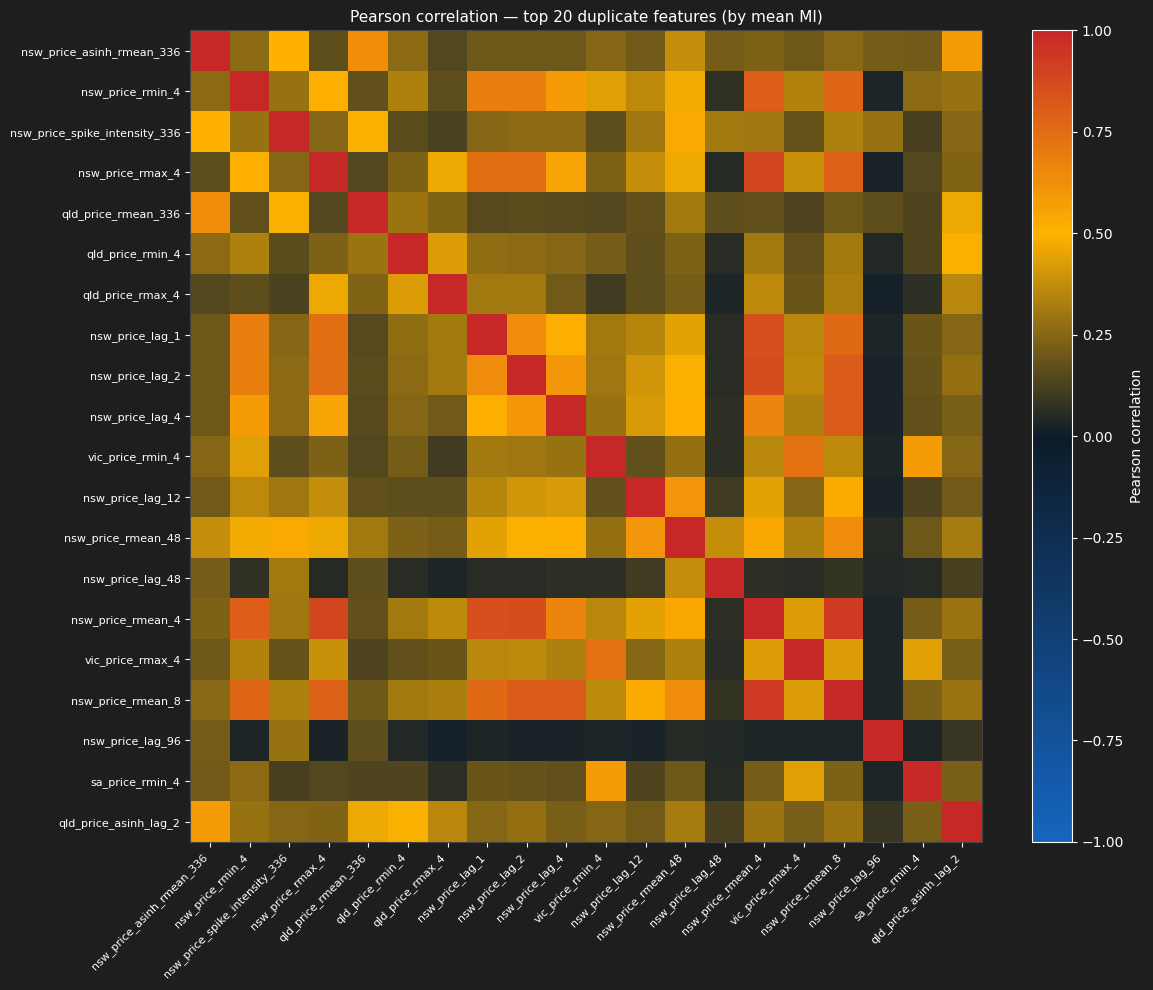

In [4]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
feature_data_flagged = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)

_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
features_subsampled = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_features_subsampled_{_stem}.parquet")
)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

TOP_N = 20

# Top N duplicate features by mean MI (highest MI duplicates — most "interesting" redundancies)
duplicate_features = (
    feature_data_flagged[feature_data_flagged["is_duplicate"] == True]
    .head(TOP_N)["feature"]
    .tolist()
)
top_features = [f for f in duplicate_features if f in features_subsampled.columns]
corr = features_subsampled[top_features].corr(method="pearson")

# Diverging colormap with accent at 75th percentile (0.5 on the -1→1 scale = position 0.75)
# blue → navy (mid) → electric cyan accent → crimson
_cmap = LinearSegmentedColormap.from_list(
    "dark_div_accent",
    [
        (0.00, "#1565C0"),   # -1.0  deep blue
        (0.50, "#0D1B2A"),   #  0.0  dark navy (midpoint)
        (0.75, "#FFB300"),   # +0.5  electric cyan accent (75th percentile)
        (1.00, "#C62828"),   # +1.0  deep crimson
    ],
)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(12, 10), facecolor="#1e1e1e")
    ax.set_facecolor("#1e1e1e")
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap=_cmap, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, label="Pearson correlation")
    cbar.ax.yaxis.label.set_color("white")
    cbar.ax.tick_params(colors="white")
    ax.set_xticks(range(len(top_features)))
    ax.set_yticks(range(len(top_features)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8, color="white")
    ax.set_yticklabels(corr.index, fontsize=8, color="white")
    ax.set_title(f"Pearson correlation — top {len(top_features)} duplicate features (by mean MI)", fontsize=11, color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    plt.tight_layout()
    plt.show()


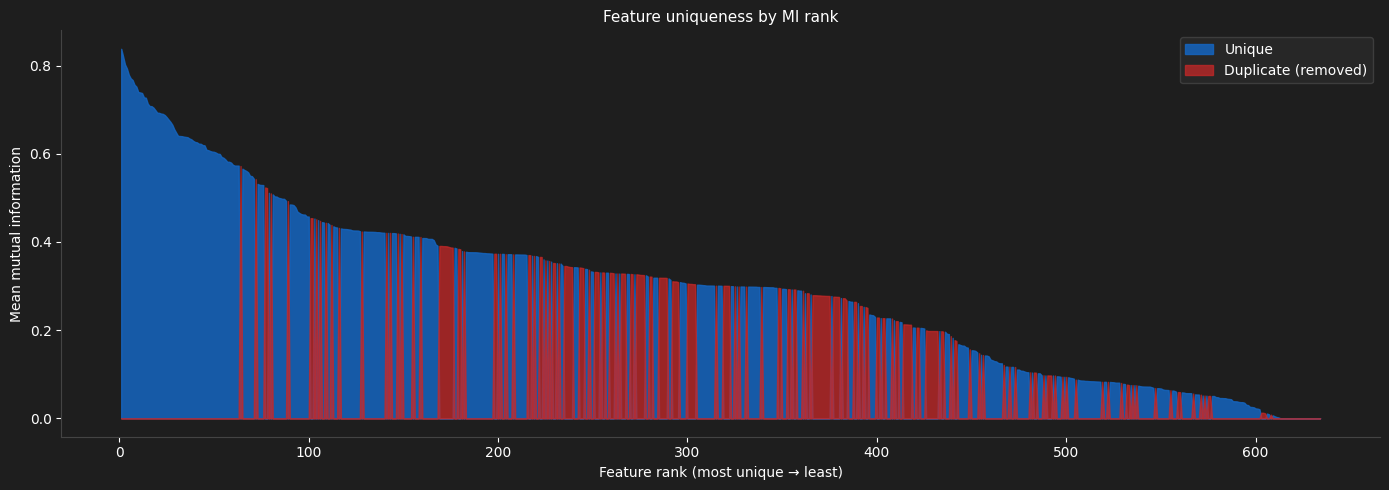

In [5]:
_stem = Path(os.environ['FEATURE_DATASET']).stem
_target = os.environ['TARGET']
feature_data_flagged = pd.read_parquet(
    resolve(f"3_Features_select/Selected_features/{_target}_feature_data_flagged_{_stem}.parquet")
)

import matplotlib.pyplot as plt

df_plot = feature_data_flagged.sort_values("mean_mi", ascending=False).reset_index(drop=True)
df_plot["rank_pos"] = range(1, len(df_plot) + 1)

unique_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == False, 0)
dup_mi = df_plot["mean_mi"].where(df_plot["is_duplicate"] == True, 0)

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(14, 5), facecolor="#1e1e1e")
    ax.set_facecolor("#1e1e1e")

    ax.fill_between(df_plot["rank_pos"], unique_mi, alpha=0.85, color="#1565C0", label="Unique")
    ax.fill_between(df_plot["rank_pos"], dup_mi, alpha=0.75, color="#C62828", label="Duplicate (removed)")

    ax.set_xlabel("Feature rank (most unique → least)", color="white", fontsize=10)
    ax.set_ylabel("Mean mutual information", color="white", fontsize=10)
    ax.set_title("Feature uniqueness by MI rank", fontsize=11, color="white")
    ax.tick_params(colors="white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_edgecolor("#444444")
    ax.spines["left"].set_edgecolor("#444444")
    ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="white")
    plt.tight_layout()
    plt.show()


In [ ]:
# Correlation matrix helper (auto-detects source if omitted)
%run 0_correlation_matrix.ipynb
plot_mi_top_features(source="unqiue", top_n=10)


In [ ]:
%reset -f